# 02 - Análise Exploratória dos Dados

## Predição de Cancelamento de Reservas Hoteleiras

Nesta etapa, vou olhar com mais detalhe para os dados e tentar entender quais características das reservas podem estar relacionadas ao cancelamento.

A variável que vou acompanhar principalmente é `is_canceled`, que indica se a reserva foi cancelada ou não.

Também vou verificar alguns problemas encontrados nos dados que podem precisar de tratamento antes de treinar os modelos.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

## 2. Carregamento dos dados

Vou utilizar o mesmo endereço do notebook anterior, diretamente do repositório do projeto.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/josepharroyoh/hotel-cancellation-ml/main/data/raw/hotel_booking.csv"
)

df = pd.read_csv(DATA_URL)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## 3. Distribuição dos cancelamentos

Primeiro, vou verificar a quantidade de reservas canceladas e não canceladas.

`is_canceled = 0` representa uma reserva que não foi cancelada e `is_canceled = 1` representa uma reserva cancelada.

In [3]:
df["is_canceled"].value_counts().sort_index()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [4]:
df["is_canceled"].value_counts(normalize=True).sort_index() * 100

is_canceled
0   62.96
1   37.04
Name: proportion, dtype: float64

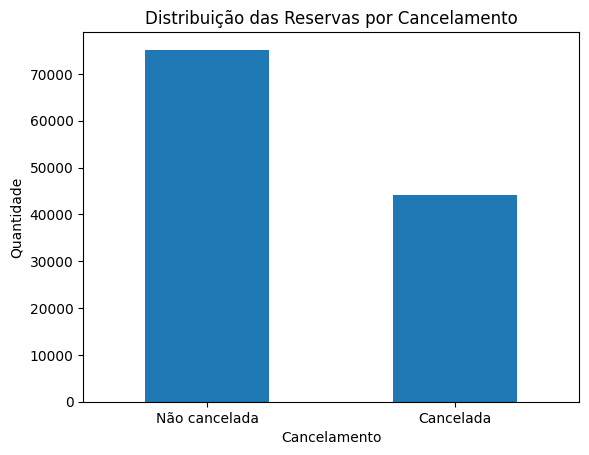

In [5]:
df["is_canceled"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribuição das Reservas por Cancelamento")
plt.xlabel("Cancelamento")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Não cancelada", "Cancelada"], rotation=0)
plt.show()

A maior parte das reservas não foi cancelada, mas os cancelamentos representam uma parcela considerável dos dados. Por isso, na etapa de modelagem não vou usar somente a acurácia para avaliar os resultados.

## 4. Cancelamento por tipo de hotel

Vou comparar os dois tipos de hotel para verificar se o comportamento dos cancelamentos é parecido.

In [6]:
taxa_hotel = df.groupby("hotel")["is_canceled"].mean() * 100
taxa_hotel.sort_values(ascending=False)

hotel
City Hotel     41.73
Resort Hotel   27.76
Name: is_canceled, dtype: float64

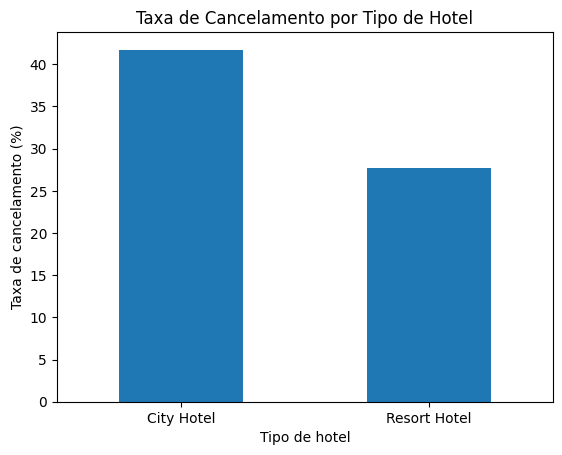

In [7]:
taxa_hotel.sort_values(ascending=False).plot(kind="bar")

plt.title("Taxa de Cancelamento por Tipo de Hotel")
plt.xlabel("Tipo de hotel")
plt.ylabel("Taxa de cancelamento (%)")
plt.xticks(rotation=0)
plt.show()

O City Hotel apresenta uma taxa de cancelamento maior que o Resort Hotel. Essa diferença pode ser útil para a previsão, então `hotel` será mantida nas próximas etapas.

## 5. Lead time

`lead_time` indica quantos dias existem entre a reserva e a chegada.

Vou verificar se as reservas canceladas costumam ter um comportamento diferente nessa variável.

In [8]:
df.groupby("is_canceled")["lead_time"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.00,79.98,91.11,0.00,9.00,45.00,124.00,737.00
1,44224.00,144.85,118.62,0.00,48.00,113.00,214.00,629.00


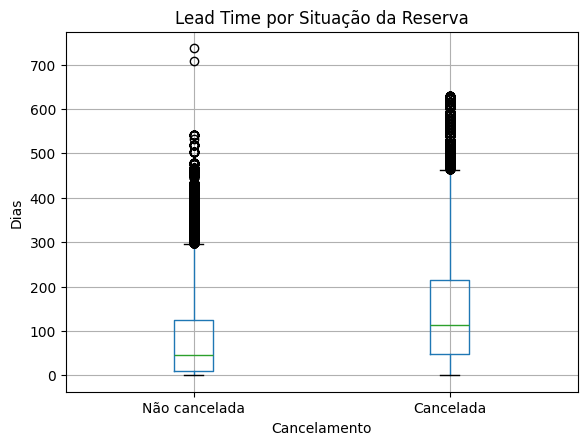

In [9]:
df.boxplot(column="lead_time", by="is_canceled")

plt.suptitle("")
plt.title("Lead Time por Situação da Reserva")
plt.xlabel("Cancelamento")
plt.ylabel("Dias")
plt.xticks([1, 2], ["Não cancelada", "Cancelada"])
plt.show()

Existe uma diferença na distribuição de `lead_time` entre as duas classes. Essa variável faz sentido para o problema porque já está disponível no momento da reserva.

## 6. Taxa de cancelamento por faixa de lead time

Para visualizar melhor essa relação, vou dividir o `lead_time` em algumas faixas.

In [10]:
df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=["0-7 dias", "8-30 dias", "31-90 dias", "91-180 dias", "181-365 dias", "Mais de 365 dias"]
)

taxa_lead_time = df.groupby("lead_time_group", observed=False)["is_canceled"].mean() * 100
taxa_lead_time

lead_time_group
0-7 dias            9.63
8-30 dias          27.86
31-90 dias         37.70
91-180 dias        44.71
181-365 dias       55.45
Mais de 365 dias   67.66
Name: is_canceled, dtype: float64

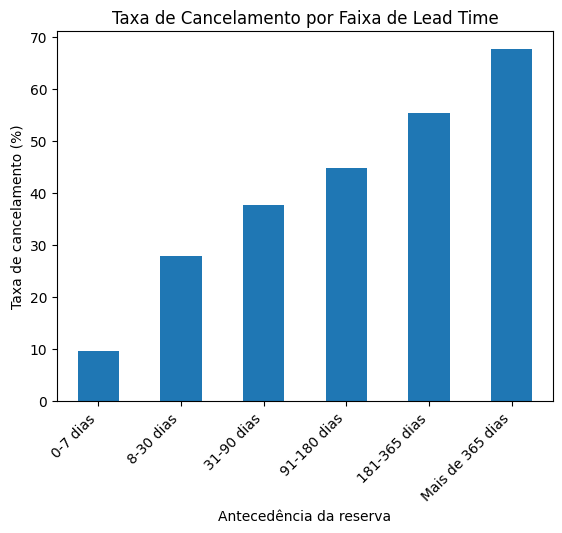

In [11]:
taxa_lead_time.plot(kind="bar")

plt.title("Taxa de Cancelamento por Faixa de Lead Time")
plt.xlabel("Antecedência da reserva")
plt.ylabel("Taxa de cancelamento (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

A taxa de cancelamento aumenta nas faixas de maior antecedência. Isso reforça a importância do `lead_time` para o problema.

A variável `lead_time_group` foi criada apenas para esta análise. A decisão de usar essa transformação no modelo será feita na preparação dos dados.

## 7. Tipo de depósito

Agora vou verificar se existe diferença na taxa de cancelamento entre os tipos de depósito.

In [12]:
taxa_deposito = df.groupby("deposit_type")["is_canceled"].mean() * 100
taxa_deposito.sort_values(ascending=False)

deposit_type
Non Refund   99.36
No Deposit   28.38
Refundable   22.22
Name: is_canceled, dtype: float64

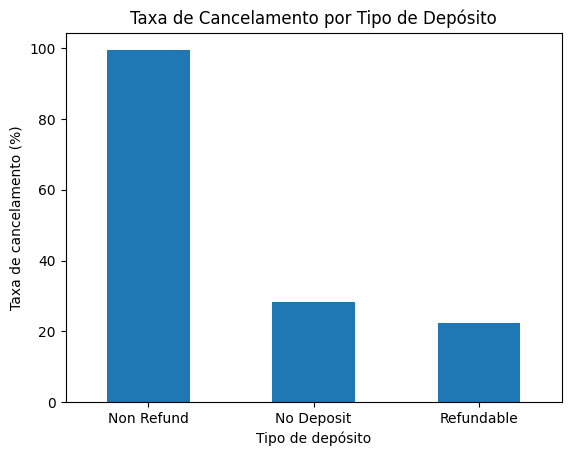

In [13]:
taxa_deposito.sort_values(ascending=False).plot(kind="bar")

plt.title("Taxa de Cancelamento por Tipo de Depósito")
plt.xlabel("Tipo de depósito")
plt.ylabel("Taxa de cancelamento (%)")
plt.xticks(rotation=0)
plt.show()

Os tipos de depósito apresentam comportamentos bem diferentes em relação ao cancelamento. Por isso, `deposit_type` parece ser uma variável importante para o modelo.

## 8. Segmento de mercado

Vou comparar a taxa de cancelamento entre os diferentes segmentos de mercado.

In [14]:
taxa_segmento = df.groupby("market_segment")["is_canceled"].mean() * 100
taxa_segmento.sort_values(ascending=False)

market_segment
Undefined       100.00
Groups           61.06
Online TA        36.72
Offline TA/TO    34.32
Aviation         21.94
Corporate        18.73
Direct           15.34
Complementary    13.06
Name: is_canceled, dtype: float64

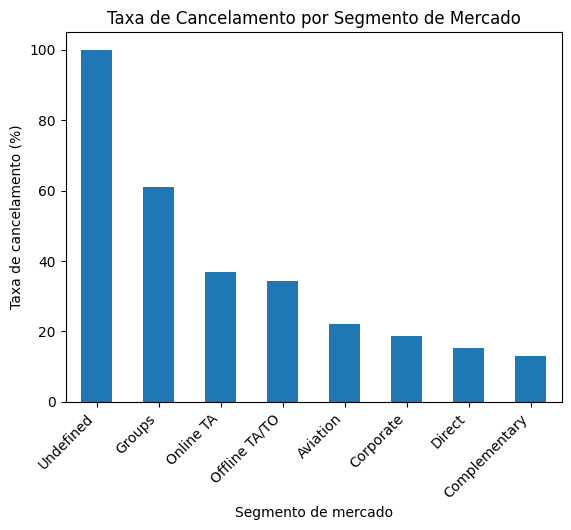

In [15]:
taxa_segmento.sort_values(ascending=False).plot(kind="bar")

plt.title("Taxa de Cancelamento por Segmento de Mercado")
plt.xlabel("Segmento de mercado")
plt.ylabel("Taxa de cancelamento (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

Também existem diferenças entre os segmentos de mercado. Essa informação pode ajudar o modelo a diferenciar alguns perfis de reserva.

## 9. Tipo de cliente

Vou fazer uma análise parecida para o tipo de cliente.

In [16]:
taxa_cliente = df.groupby("customer_type")["is_canceled"].mean() * 100
taxa_cliente.sort_values(ascending=False)

customer_type
Transient         40.75
Contract          30.96
Transient-Party   25.43
Group             10.23
Name: is_canceled, dtype: float64

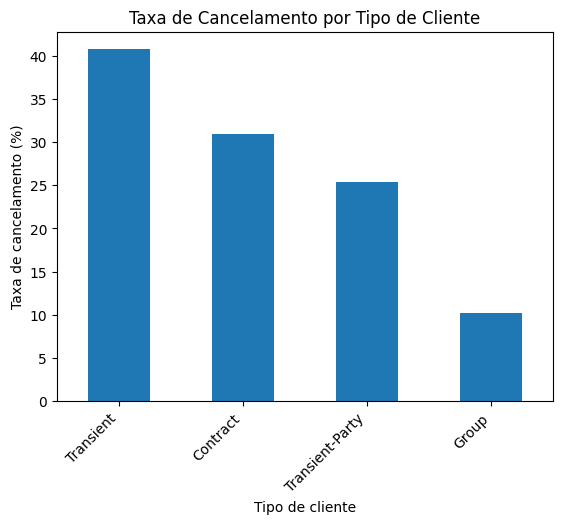

In [17]:
taxa_cliente.sort_values(ascending=False).plot(kind="bar")

plt.title("Taxa de Cancelamento por Tipo de Cliente")
plt.xlabel("Tipo de cliente")
plt.ylabel("Taxa de cancelamento (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

As taxas também mudam de acordo com o tipo de cliente. Vou manter essa variável para avaliar sua contribuição nos modelos.

## 10. Histórico de cancelamentos

Também quero verificar se o histórico do cliente tem relação com o cancelamento atual.

In [18]:
df.groupby("previous_cancellations")["is_canceled"].agg(["count", "mean"]).sort_values(
    "mean", ascending=False
).head(15)

,count,mean
previous_cancellations,,
24,48,1.00
26,26,1.00
25,25,1.00
21,1,1.00
19,19,1.00
14,14,1.00
1,6051,0.94
13,12,0.92
0,112906,0.34


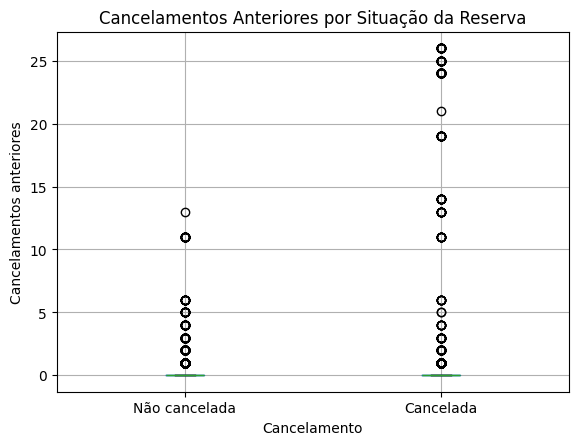

In [19]:
df.boxplot(column="previous_cancellations", by="is_canceled")

plt.suptitle("")
plt.title("Cancelamentos Anteriores por Situação da Reserva")
plt.xlabel("Cancelamento")
plt.ylabel("Cancelamentos anteriores")
plt.xticks([1, 2], ["Não cancelada", "Cancelada"])
plt.show()

O histórico de cancelamentos mostra uma diferença clara entre os grupos. Essa informação pode ser útil para identificar clientes com maior risco de cancelar novamente.

## 11. Solicitações especiais

Vou verificar se o número de solicitações especiais também apresenta alguma relação com o cancelamento.

In [20]:
taxa_solicitacoes = df.groupby("total_of_special_requests")["is_canceled"].mean() * 100
taxa_solicitacoes

total_of_special_requests
0   47.72
1   22.02
2   22.10
3   17.86
4   10.59
5    5.00
Name: is_canceled, dtype: float64

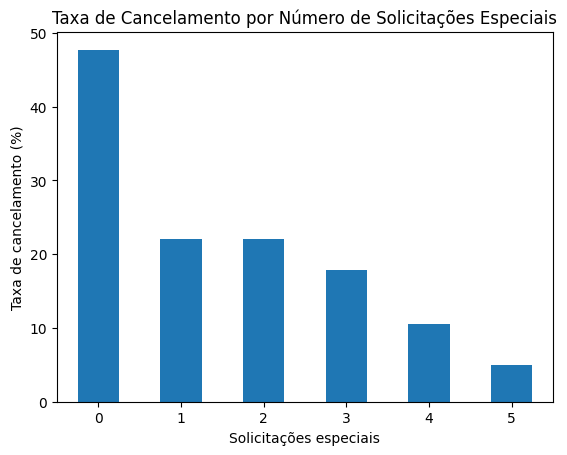

In [21]:
taxa_solicitacoes.plot(kind="bar")

plt.title("Taxa de Cancelamento por Número de Solicitações Especiais")
plt.xlabel("Solicitações especiais")
plt.ylabel("Taxa de cancelamento (%)")
plt.xticks(rotation=0)
plt.show()

Existe uma diferença na taxa de cancelamento conforme o número de solicitações especiais. Vou manter essa variável para os próximos testes.

## 12. Duração da estadia

Vou criar `total_nights` para analisar a duração total da estadia.

In [22]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
)

df.groupby("is_canceled")["total_nights"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.00,3.39,2.58,0.00,2.00,3.00,4.00,69.00
1,44224.00,3.49,2.52,0.00,2.00,3.00,4.00,56.00


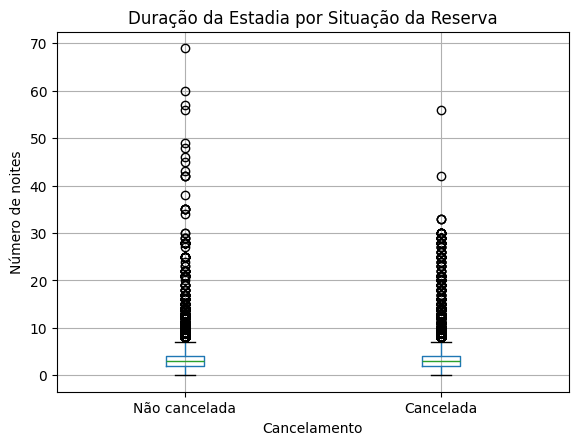

In [23]:
df.boxplot(column="total_nights", by="is_canceled")

plt.suptitle("")
plt.title("Duração da Estadia por Situação da Reserva")
plt.xlabel("Cancelamento")
plt.ylabel("Número de noites")
plt.xticks([1, 2], ["Não cancelada", "Cancelada"])
plt.show()

A duração da estadia também apresenta diferenças entre as reservas. Vou considerar `total_nights` como uma possível variável criada a partir dos dados originais.

## 13. Número de hóspedes

Vou criar uma variável com o número total de pessoas da reserva.

In [24]:
df["total_guests"] = (
    df["adults"] + df["children"].fillna(0) + df["babies"]
)

df.groupby("is_canceled")["total_guests"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.00,1.94,0.67,0.00,2.00,2.00,2.00,12.00
1,44224.00,2.01,0.80,0.00,2.00,2.00,2.00,55.00


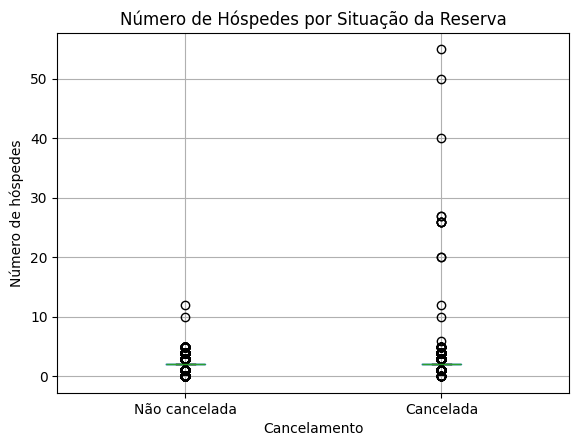

In [25]:
df.boxplot(column="total_guests", by="is_canceled")

plt.suptitle("")
plt.title("Número de Hóspedes por Situação da Reserva")
plt.xlabel("Cancelamento")
plt.ylabel("Número de hóspedes")
plt.xticks([1, 2], ["Não cancelada", "Cancelada"])
plt.show()

O número de hóspedes ajuda a representar o perfil da reserva. Essa variável também pode ser útil quando combinada com outras características.

## 14. ADR

`adr` representa a tarifa média diária.

No notebook anterior já foi identificado que essa variável possui valores extremos. Aqui vou olhar sua distribuição e verificar se existe diferença entre as reservas canceladas e não canceladas.

In [26]:
df.groupby("is_canceled")["adr"].describe()

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.00,99.99,49.21,-6.38,67.50,92.50,125.00,510.00
1,44224.00,104.96,52.57,0.00,72.42,96.20,127.62,5400.00


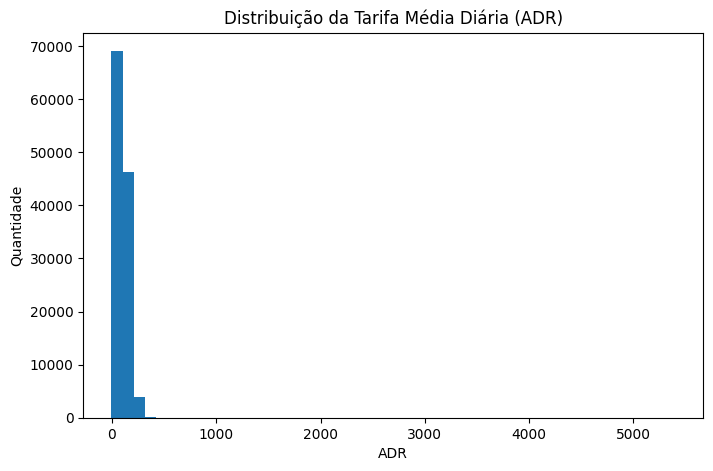

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(df["adr"], bins=50)

plt.title("Distribuição da Tarifa Média Diária (ADR)")
plt.xlabel("ADR")
plt.ylabel("Quantidade")
plt.show()

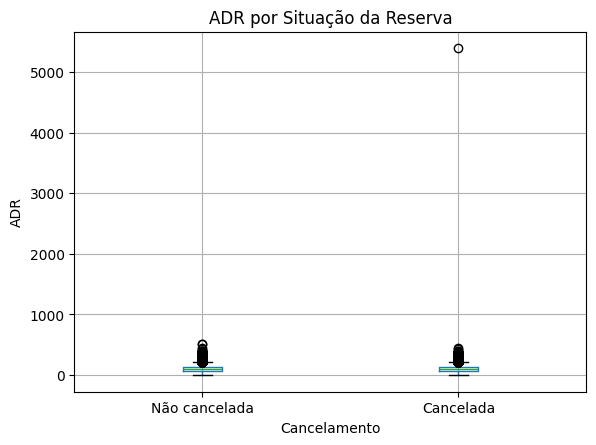

In [28]:
df.boxplot(column="adr", by="is_canceled")

plt.suptitle("")
plt.title("ADR por Situação da Reserva")
plt.xlabel("Cancelamento")
plt.ylabel("ADR")
plt.xticks([1, 2], ["Não cancelada", "Cancelada"])
plt.show()

In [29]:
df["adr"].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])

count   119390.00
mean       101.83
std         50.54
min         -6.38
1%           0.00
5%          38.40
50%         94.58
95%        193.50
99%        252.00
max       5400.00
Name: adr, dtype: float64

In [30]:
df[df["adr"] < 0][
    ["hotel", "is_canceled", "adr", "arrival_date_year", "arrival_date_month"]
]

,hotel,is_canceled,adr,arrival_date_year,arrival_date_month
14969,Resort Hotel,0,-6.38,2017,March


A distribuição de `adr` é bastante assimétrica e possui valores extremos. Também existe pelo menos um valor negativo, que não faz sentido como tarifa.

Não vou excluir esses valores diretamente nesta etapa. Vou deixar esse tratamento para o notebook de preparação, onde será possível definir uma regra e verificar seu efeito.

## 15. Correlação das variáveis numéricas

Vou olhar rapidamente para a correlação das variáveis numéricas com `is_canceled`.

Essa análise serve apenas como referência. Não vou usar a correlação como único critério para escolher as variáveis do modelo.

In [31]:
numericas = df.select_dtypes(include=["int64", "float64"]).columns

correlacao = df[numericas].corr()

correlacao["is_canceled"].sort_values(ascending=False)

is_canceled                       1.00
lead_time                         0.29
previous_cancellations            0.11
adults                            0.06
days_in_waiting_list              0.05
adr                               0.05
total_guests                      0.05
stays_in_week_nights              0.02
total_nights                      0.02
arrival_date_year                 0.02
arrival_date_week_number          0.01
children                          0.01
stays_in_weekend_nights          -0.00
arrival_date_day_of_month        -0.01
company                          -0.02
babies                           -0.03
previous_bookings_not_canceled   -0.06
agent                            -0.08
is_repeated_guest                -0.08
booking_changes                  -0.14
required_car_parking_spaces      -0.20
total_of_special_requests        -0.23
Name: is_canceled, dtype: float64

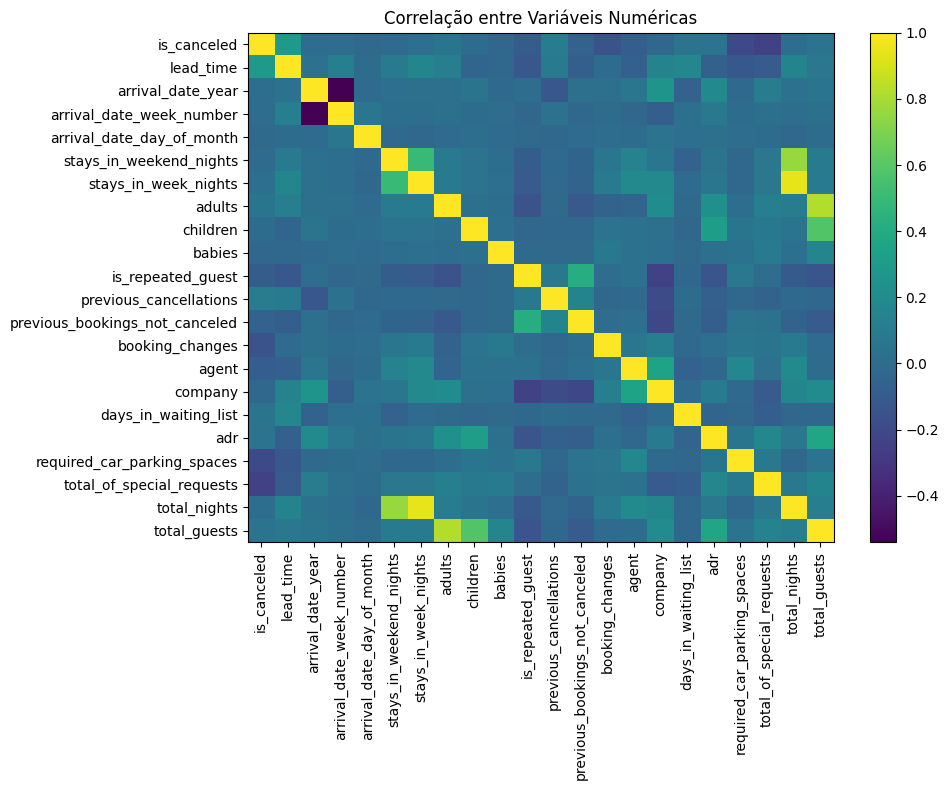

In [32]:
plt.figure(figsize=(10, 8))

plt.imshow(correlacao, aspect="auto")
plt.colorbar()

plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=90)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)

plt.title("Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.show()

A correlação ajuda a ter uma visão geral dos dados, mas não é suficiente para decidir quais variáveis serão utilizadas. Também vou considerar o significado de cada variável, o momento em que ela estaria disponível e o risco de data leakage.

## 16. O que levo desta análise

Alguns pontos ficaram mais claros nesta etapa:

- o cancelamento não está distribuído igualmente entre os tipos de hotel;
- `lead_time` apresenta uma relação clara com a taxa de cancelamento;
- o tipo de depósito apresenta diferenças importantes;
- o segmento de mercado e o tipo de cliente também apresentam comportamentos diferentes;
- o histórico de cancelamentos pode ser útil para a previsão;
- `total_nights` e `total_guests` podem representar melhor algumas características da reserva;
- `adr` precisa de uma análise e tratamento antes do treinamento;
- nem todas as variáveis do dataset devem entrar no modelo, principalmente quando a informação não estaria disponível no momento da previsão.

Na próxima etapa vou preparar os dados para o treinamento dos modelos e definir quais variáveis realmente serão utilizadas.